# 1. Data and model fitting

Start here before the evaluation notebooks. The inputs are processed within-event
residuals in `data/common_records.csv` and the nine CSVs in `data/periods/`.
The full dataset permits missing periods; the complete dataset retains only
station-event records observed at all nine periods. No values are imputed.

By default this notebook **loads the supplied fitted models** and rebuilds the
data table and geometry figure. Set `RUN_FULL_FIT` or `RUN_COMPLETE_FIT` to `True`
to fit from the CSVs and replace the corresponding PKL. The fitting functions
start from data and do not need an existing model file. LMC likelihood fits are
the slowest steps. Runtime depends strongly on the BLAS library and machine.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts/models').is_dir())
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from threadpoolctl import threadpool_limits
from scripts.analysis.model_fit.workflow import (
    MODEL_DIR, prepare_data, fit_models, load_models, data_summary, model_summary,
)

RUN_FULL_FIT = False
RUN_COMPLETE_FIT = False
THREADS = 4
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES = ROOT / 'results/figures'
FIGURES.mkdir(parents=True, exist_ok=True)

## Prepare data and empirical semivariograms

`prepare_data` reads CSVs, forms period pairs, computes the 2 km empirical bins
through 100 km, and computes colocated correlations. The complete-case version
first filters the outer-joined residual panel and then recomputes all targets.
This cell performs data preparation, not model fitting.

In [2]:
with threadpool_limits(limits=THREADS):
    full_data = prepare_data('full')
    complete_data = prepare_data('complete')

display(data_summary(full_data))  # Manuscript Table 1
display(pd.DataFrame([
    dict(dataset='full', events=len(set().union(*(set(f.eqid) for f in full_data.period_dfs))),
         observed_residuals=sum(len(f) for f in full_data.period_dfs)),
    dict(dataset='complete', events=len(complete_data.events_pca),
         observed_residuals=len(complete_data.df_pca) * len(complete_data.periods)),
]))

,period_s,events,records,station_locations,median_stations_per_event,min_stations_per_event,max_stations_per_event,station_pairs
0,0.01,134,13898,2941,76.5,40,542,1169078
1,0.03,134,13898,2941,76.5,40,542,1169078
2,0.06,134,13898,2941,76.5,40,542,1169078
3,0.10,134,13897,2941,76.5,40,542,1169004
4,0.30,134,13891,2941,76.5,40,542,1168626
5,0.60,134,13846,2941,76.0,40,542,1164864
6,1.00,128,13342,2937,76.0,40,542,1140275
7,3.00,66,7997,2780,78.5,41,542,843626
8,6.00,41,5558,2451,79.0,40,539,678938


,dataset,events,observed_residuals
0,full,134,110225
1,complete,41,49995


## Fit the full dataset: `models.pkl`

The eight families give ten fitted variants: Pairwise, GH08, separable kernel,
PCA (semivariogram and MLE), LMC (semivariogram and MLE), IOX, SBSS, and
multivariate Matérn. PCA and SBSS use complete residual vectors as required by
their fitting methods. The other full-data methods use available observations.

Semivariogram fits use 45 unique period pairs where cross pairs are fitted;
the separable spatial kernel uses the nine direct semivariograms. LMC uses
30 weighted Goulard sweeps. Full-data LMC MLE follows the original three stages:
complete records capped at 80 stations, full data capped at 80, then all full-data
stations (250, 250, and 150 iterations; ridge `1e-6`, `ftol=1e-7`, `gtol=1e-4`).
The supplied full-data LMC reaches the final iteration limit; it is the selected
finite-iteration fit used for the article, not a claim of a global optimum.

In [3]:
if RUN_FULL_FIT:
    with threadpool_limits(limits=THREADS):
        models, full_fit_times = fit_models(
            dataset='full', data=full_data, output=MODEL_DIR / 'models.pkl',
        )
    display(full_fit_times)
else:
    models = load_models('full')
    print('Loaded supplied full-data fit; optimization was not rerun.')

display(model_summary(models, 'full'))

Loaded supplied full-data fit; optimization was not rerun.


,model,periods,distance_points,maximum_distance_km
0,Pairwise empirical semivariogram,9,400,120.0
1,GH08 semivariogram,9,400,120.0
2,PCA semivariogram,9,400,120.0
3,PCA MLE,9,400,120.0
4,Kronecker semivariogram,9,400,120.0
5,LMC block MLE,9,400,120.0
6,LMC semivariogram,9,400,120.0
7,IOX full semivariogram,9,400,120.0
8,SBSS semivariogram,9,400,120.0
9,Multivariate Matern semivariogram,9,1001,100.0


## Fit the complete dataset: `models_complete.pkl`

The five complete-case variants are separable, PCA semivariogram, PCA MLE,
LMC semivariogram, and LMC MLE. PCA is fitted again from the complete inputs.
The LMC semivariogram fit uses the same 30 weighted Goulard sweeps.

Complete-case LMC MLE uses every complete observation, zero residual mean,
no station cap, no ridge, and sample-covariance-scaled Cholesky coordinates.
Its covariance and likelihood are unchanged by that coordinate transformation.
The selected recipe takes 110 iterations at `gtol=1e-5`, then checks convergence
at `gtol=1e-4` (`ftol=1e-9`). This reproduces the stopping recipe of the supplied
fit; optimizer/BLAS differences can change the final small digits.

In [4]:
if RUN_COMPLETE_FIT:
    with threadpool_limits(limits=THREADS):
        models_complete, complete_fit_times = fit_models(
            dataset='complete', data=complete_data,
            output=MODEL_DIR / 'models_complete.pkl',
        )
    display(complete_fit_times)
else:
    models_complete = load_models('complete')
    print('Loaded supplied complete-case fit; optimization was not rerun.')

display(model_summary(models_complete, 'complete'))

Loaded supplied complete-case fit; optimization was not rerun.


,model,periods,distance_points,maximum_distance_km
0,Kronecker semivariogram,9,400,120.0
1,PCA MLE,9,400,120.0
2,PCA semivariogram,9,400,120.0
3,LMC block MLE,9,400,120.0
4,LMC semivariogram,9,400,120.0


## Inspect the fitted parameters

Each PKL contains `data_state`, the fitted parameter dictionaries, and correlation
curves in `cross_period_psd['curves']`. The later notebooks load the appropriate
PKL. The shared curve-key name is historical: the PSD experiment itself is run
separately in its own notebook. Fixed selections for data-requirement experiments
are in `results/analysis/model_fit/samples/`; they are not required to fit these
two main model archives.

In [5]:
display(pd.DataFrame({
    'component': range(1, len(models['pca']['mle']['LE']) + 1),
    'length_km': models['pca']['mle']['LE'],
    'exponent': models['pca']['mle']['gammaE'],
}))
display(pd.DataFrame([
    dict(dataset=dataset, objective_per_observation=payload['lmc_block_mle']['nll'],
         optimizer_success=payload['lmc_block_mle']['success'],
         optimizer_message=payload['lmc_block_mle']['message'])
    for dataset, payload in [('full', models), ('complete', models_complete)]
]))

,component,length_km,exponent
0,1,30.265852,0.355312
1,2,21.150934,0.452153
2,3,29.399071,0.465586
3,4,13.018333,0.379189
4,5,8.967486,0.355154
5,6,1.862533,0.344723
6,7,3.458458,0.292941
7,8,1.000000,0.297500
8,9,1.259859,0.196650


,dataset,objective_per_observation,optimizer_success,optimizer_message
0,full,0.527057,False,STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
1,complete,0.485249,True,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL


## Plot data geometry — manuscript Figure 1

The two panels use the 0.1 s and 6 s period datasets. The plot is calculated
from the input station coordinates and within-event station pairs.

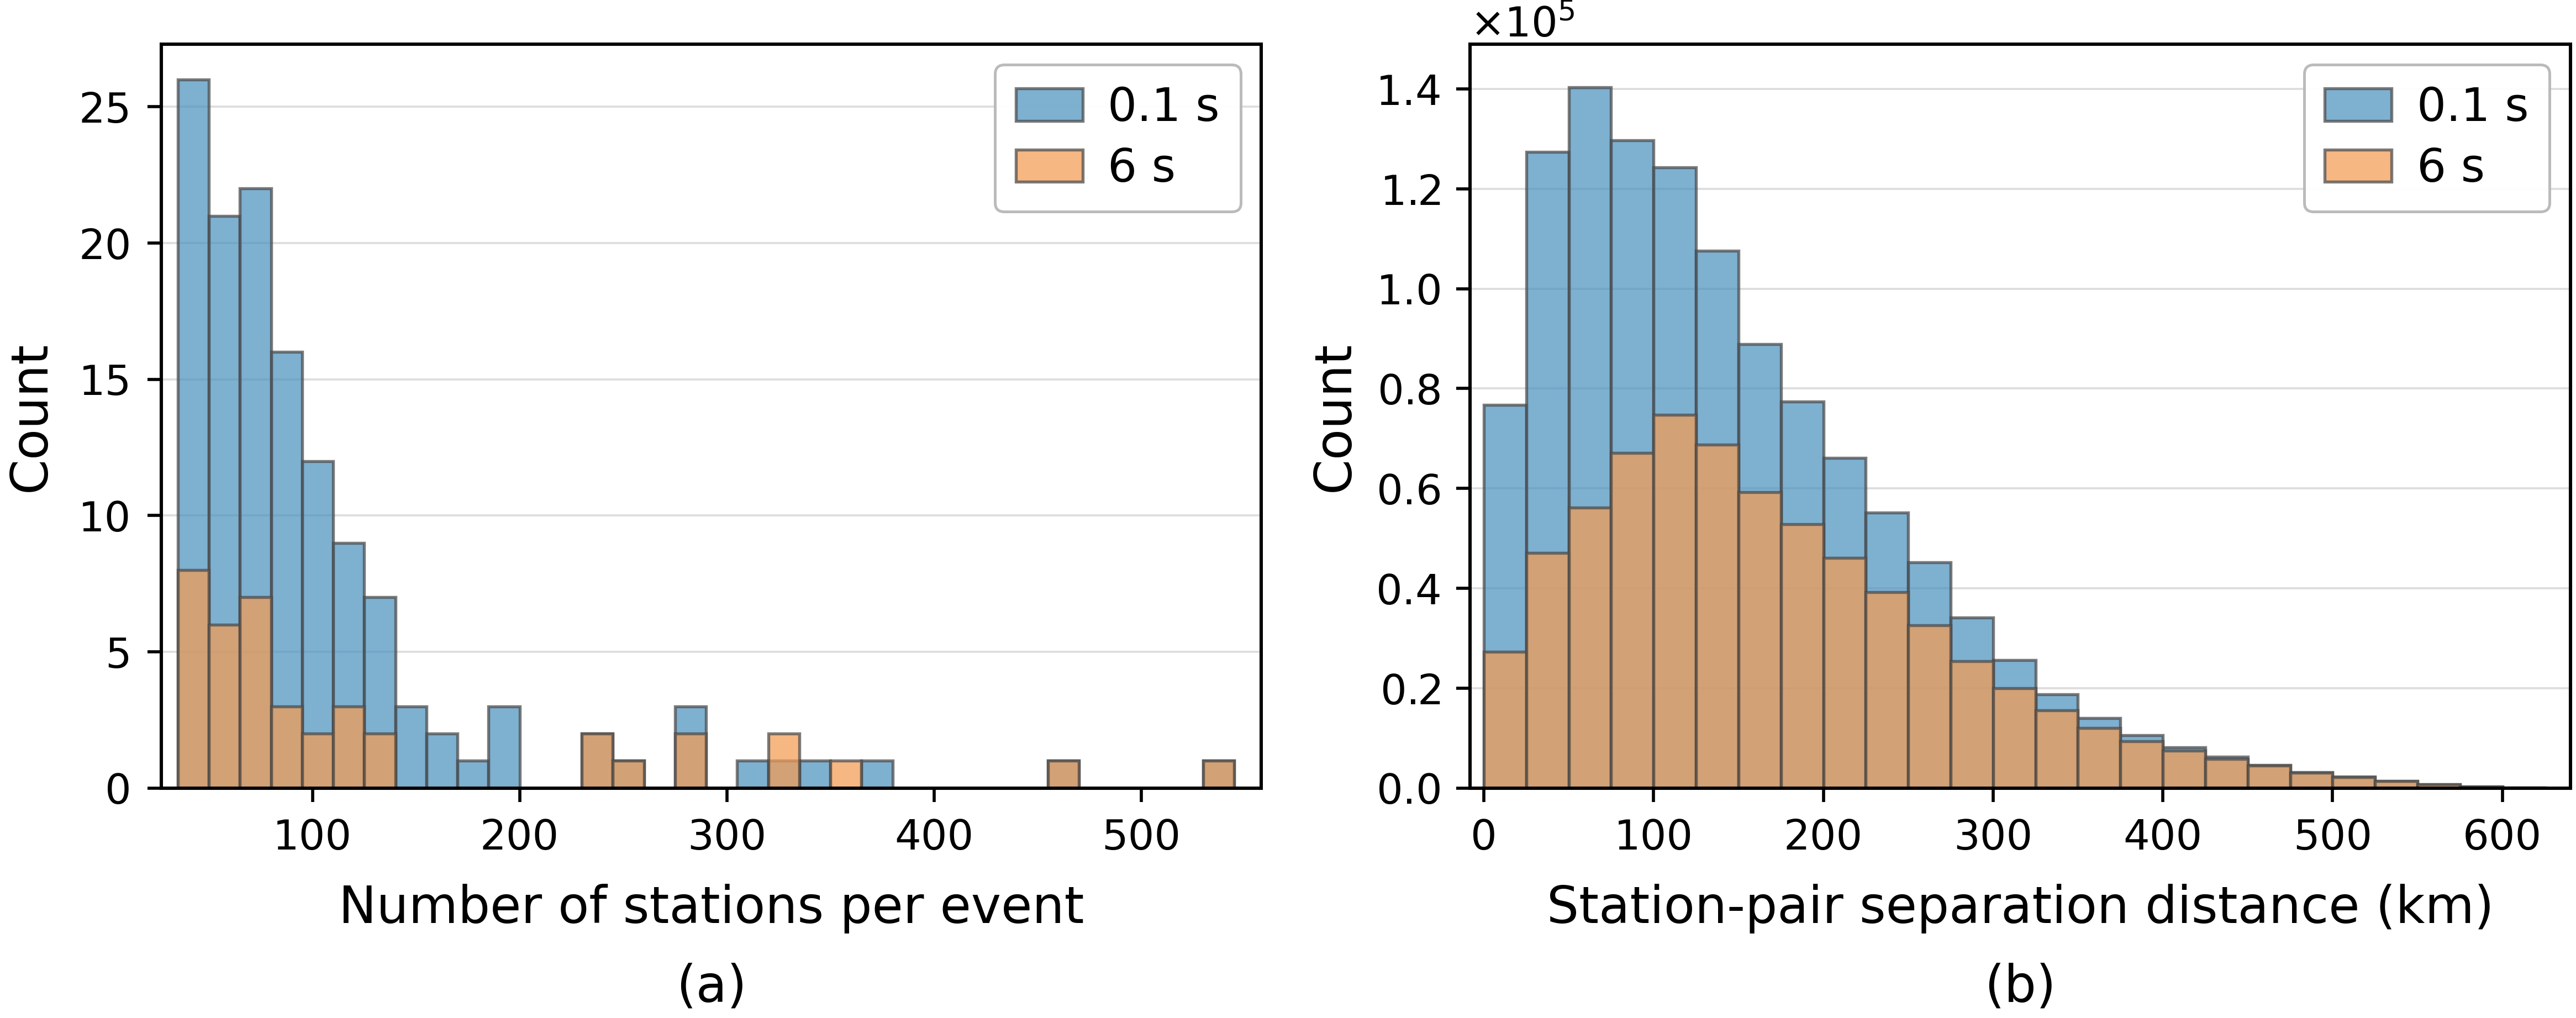

In [6]:
from scripts.common.plotting import make_data_figure

frames = {float(period): frame for period, frame in zip(full_data.periods, full_data.period_dfs)
          if float(period) in (0.1, 6.0)}
figure = make_data_figure(frames)
figure.savefig(FIGURES / 'fig01_data_characteristics.png', dpi=300,
               bbox_inches='tight', pad_inches=0.035)
display(Image(filename=str(FIGURES / 'fig01_data_characteristics.png')))
plt.close(figure)

## Rerun only selected models

For a short fitting check, run the following in a new cell. With no `initial`,
the returned object contains only the selected fresh fits. No PKL is changed
unless `output` is supplied. To update selected models in a full archive,
explicitly pass `initial=models` and the intended output path.

```python
with threadpool_limits(limits=THREADS):
    selected, timing = fit_models(
        'full', models=['gh08', 'pca'], method='semivariogram', data=full_data,
    )
display(timing)
```

The command-line alternatives use the same fitting code:

```bash
python -m scripts.fitting.semivariogram --dataset full
python -m scripts.fitting.mle --dataset full --models pca lmc
python -m scripts.fitting.semivariogram --dataset complete
python -m scripts.fitting.mle --dataset complete --models pca lmc
```

The CLIs update their dataset's PKL, retaining other fitted variants. Use
`--output another_path.pkl` to keep the supplied archive, or `--fresh` to begin
an archive without existing fits. Continue with PSD, predictive accuracy,
structural flexibility, data requirements, and computation notebooks.